In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import os

In [2]:
# Contoh data, misalnya kita memiliki data dalam bentuk DataFrame
data_normal = pd.read_csv('normal_train_edit.csv')

In [3]:
# Daftar nama file CSV
csv_files = [
    "ARP_Spoofing_Attack.csv",
    "MQTT_Attack.csv",
    "Recon_Attack.csv",
    "TCP_IP_DDoS_Attack.csv",
    "TCP_IP_DoS_Attack.csv"
]

# Membaca setiap file CSV dan menyimpannya dalam daftar DataFrame
dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)

# Menggabungkan semua DataFrame menjadi satu
data_serangan = pd.concat(dataframes, ignore_index=True)

# Menampilkan beberapa baris pertama dari DataFrame gabungan
print(data_serangan.head())

   Header_Length  Protocol Type  Duration          Rate         Srate  Drate  \
0          866.6           10.4      64.0  45722.390222  45722.390222    0.0   
1         3934.3           12.6     131.2  35708.799475  35708.799475    0.0   
2         5592.8           12.6      97.6     66.403506     66.403506    0.0   
3         9303.6           14.8      80.8     51.201280     51.201280    0.0   
4         8592.4           12.6      98.6     42.706455     42.706455    0.0   

   fin_flag_number  syn_flag_number  rst_flag_number  psh_flag_number  ...  \
0              0.0              0.0              0.0              0.3  ...   
1              0.0              0.0              0.0              0.3  ...   
2              0.0              0.0              0.0              0.3  ...   
3              0.0              0.0              0.0              0.1  ...   
4              0.0              0.0              0.0              0.2  ...   

          Std  Tot size           IAT  Number   Ma

In [4]:
data_train = pd.concat([data_normal, data_serangan], ignore_index=True)
data_train

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,134.300000,7.1,64.0,40415.288318,40415.288318,0.0,0.0,0.0,0.0,0.5,...,48.225852,95.300000,1.694641e+08,5.500000,15.312231,68.201654,2644.242675,0.900000,38.500000,0
1,137.000000,4.7,49.9,58749.191833,58749.191833,0.0,0.0,0.0,0.0,0.2,...,59.753361,125.600000,1.694641e+08,13.500000,13.468364,84.997147,5328.483794,1.000000,244.600000,0
2,283.900000,6.0,64.0,3.497439,3.497439,0.0,0.0,0.0,0.0,0.5,...,10.223690,80.600000,8.070469e-05,5.500000,12.229315,14.458481,124.725884,0.900000,38.500000,0
3,297.300000,6.0,64.0,7297.703020,7297.703020,0.0,0.0,0.0,0.0,0.5,...,15.625023,78.500000,1.694641e+08,13.500000,12.552920,21.904691,240.536207,1.000000,244.600000,0
4,572.300000,7.1,57.7,2.549120,2.549120,0.0,0.0,0.0,0.0,0.4,...,69.738867,139.000000,9.993820e-02,5.500000,13.928729,98.625651,11737.768847,0.900000,38.500000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7160826,13234.910000,17.0,64.0,29460.045053,29460.045053,0.0,0.0,0.0,0.0,0.0,...,5.968139,51.740000,8.467524e+07,9.500000,10.164175,8.453393,279.410488,0.130000,141.550000,4
7160827,18136.530000,17.0,64.0,29318.535060,29318.535060,0.0,0.0,0.0,0.0,0.0,...,2.126578,50.620000,8.467524e+07,9.500000,10.060924,3.012129,35.475423,0.130000,141.550000,4
7160828,23038.040000,17.0,64.0,29363.556139,29363.556139,0.0,0.0,0.0,0.0,0.0,...,2.321811,50.510000,8.467524e+07,9.500000,10.075262,3.287396,34.963050,0.160000,141.550000,4
7160829,58526.160000,17.0,64.0,26168.955034,26168.955034,0.0,0.0,0.0,0.0,0.0,...,147.975762,170.680000,8.467524e+07,9.500000,18.631072,205.641671,70932.249555,0.350000,141.550000,4


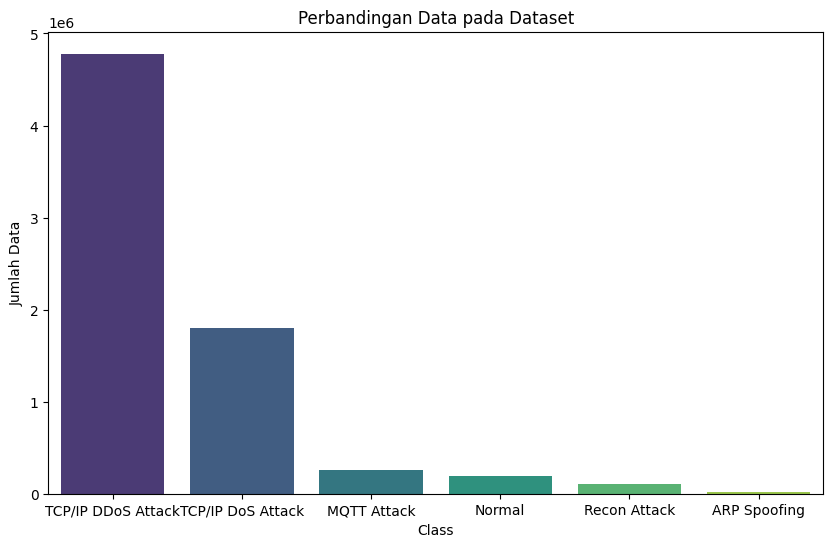

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mengubah label sesuai dengan permintaan
label_mapping = {
    0: 'Normal',
    1: 'ARP Spoofing',
    2: 'Recon Attack',
    3: 'MQTT Attack',
    4: 'TCP/IP DoS Attack',
    5: 'TCP/IP DDoS Attack'
}

# Menghitung jumlah sampel untuk setiap kelas
class_counts = data_train['label'].map(label_mapping).value_counts()

# Membuat bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts, hue=class_counts.index, palette='viridis', dodge=False, legend=False)
plt.xlabel('Class')
plt.ylabel('Jumlah Data')
plt.title('Perbandingan Data pada Dataset')
plt.show()

In [14]:
class_counts

label
TCP/IP DDoS Attack    4779859
TCP/IP DoS Attack     1805529
MQTT Attack            262938
Normal                 192732
Recon Attack           103726
ARP Spoofing            16047
Name: count, dtype: int64

In [8]:
# Contoh data, misalnya kita memiliki data dalam bentuk DataFrame
data_normal_test = pd.read_csv(r'D:\Belajar_Security\DDoS\IoMT\5_class\test\normal_test.csv')

In [9]:
# Daftar nama file CSV
csv_files_1 = [
    r"D:\Belajar_Security\DDoS\IoMT\5_class\test\ARP_Spoofing_Attack.csv",
    r"D:\Belajar_Security\DDoS\IoMT\5_class\test\MQTT_Attack.csv",
    r"D:\Belajar_Security\DDoS\IoMT\5_class\test\Recon_Attack.csv",
    r"D:\Belajar_Security\DDoS\IoMT\5_class\test\TCP_IP_DDoS_Attack.csv",
    r"D:\Belajar_Security\DDoS\IoMT\5_class\test\TCP_IP_DoS_Attack.csv"
]

# Membaca setiap file CSV dan menyimpannya dalam daftar DataFrame
dataframes = []
for file in csv_files_1:
    df = pd.read_csv(file)
    dataframes.append(df)

# Menggabungkan semua DataFrame menjadi satu
data_serangan_test = pd.concat(dataframes, ignore_index=True)

# Menampilkan beberapa baris pertama dari DataFrame gabungan
print(data_serangan_test.head())

   Header_Length  Protocol Type  Duration           Rate          Srate  \
0         3609.0           17.0      64.0     212.961498     212.961498   
1         9531.4           17.0      64.0     442.954430     442.954430   
2         6372.4           11.5      64.0   28457.581790   28457.581790   
3          129.2            6.0      64.0  105851.136945  105851.136945   
4        12130.7           14.8      81.4    4896.846315    4896.846315   

   Drate  fin_flag_number  syn_flag_number  rst_flag_number  psh_flag_number  \
0    0.0              0.0              0.0              0.0              0.0   
1    0.0              0.0              0.0              0.0              0.0   
2    0.0              0.0              0.0              0.0              0.3   
3    0.0              0.0              0.0              0.0              0.5   
4    0.0              0.0              0.0              0.0              0.1   

   ...         Std  Tot size           IAT  Number   Magnitue      R

In [10]:
data_test = pd.concat([data_normal_test, data_serangan_test], ignore_index=True)
data_test

,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,138.2,7.1,83.1,39123.054540,39123.054540,0.0,0.0,0.0,0.0,0.5,...,58.513912,99.0,1.694703e+08,5.5,15.954786,82.751168,3899.571692,0.9,38.500000,0
1,86.0,4.2,44.8,72928.095973,72928.095973,0.0,0.0,0.0,0.0,0.3,...,44.556792,64.4,1.694703e+08,13.5,13.405243,63.022662,1993.712535,1.0,244.600000,0
2,171.4,4.1,32.0,52552.111857,52552.111857,0.0,0.0,0.0,0.0,0.2,...,148.485766,152.1,9.108920e-02,5.5,14.407632,209.990584,42487.982728,0.9,38.500000,0
3,227.8,6.0,64.0,24502.562704,24502.562704,0.0,0.0,0.0,0.0,0.5,...,214.732903,80.2,1.694703e+08,13.5,15.986909,304.317403,46658.604609,1.0,244.600000,0
4,347.6,7.1,64.0,6263.156480,6263.156480,0.0,0.0,0.0,0.0,0.5,...,116.233361,162.5,9.976871e-02,5.5,15.169114,164.378795,30786.754577,0.9,38.500000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1614177,22175.0,17.0,64.0,25178.592879,25178.592879,0.0,0.0,0.0,0.0,0.0,...,0.000000,50.0,8.467917e+07,9.5,10.000000,0.000000,0.000000,0.0,141.550000,4
1614178,27175.0,17.0,64.0,24857.241994,24857.241994,0.0,0.0,0.0,0.0,0.0,...,0.000000,50.0,8.467917e+07,9.5,10.000000,0.000000,0.000000,0.0,141.550000,4
1614179,32175.0,17.0,64.0,25321.963219,25321.963219,0.0,0.0,0.0,0.0,0.0,...,0.000000,50.0,8.467917e+07,9.5,10.000000,0.000000,0.000000,0.0,141.550000,4
1614180,37175.0,17.0,64.0,21805.072220,21805.072220,0.0,0.0,0.0,0.0,0.0,...,0.000000,50.0,8.467917e+07,9.5,10.000000,0.000000,0.000000,0.0,141.550000,4


C:\Users\diash\AppData\Local\Temp\ipykernel_18916\2293252639.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


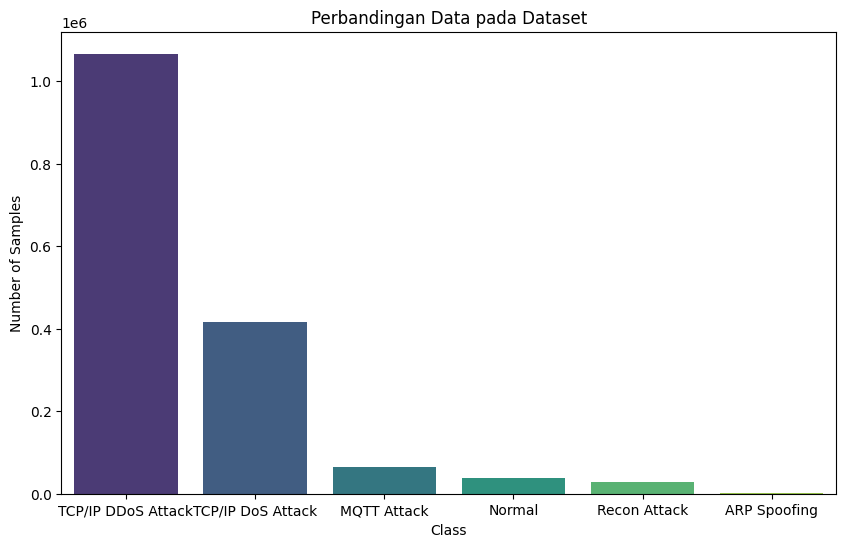

In [11]:
import matplotlib.pyplot as plt

# Mengubah label sesuai dengan permintaan
label_mapping = {
    0: 'Normal',
    1: 'ARP Spoofing',
    2: 'Recon Attack',
    3: 'MQTT Attack',
    4: 'TCP/IP DoS Attack',
    5: 'TCP/IP DDoS Attack'
}

# Menghitung jumlah sampel untuk setiap kelas
class_counts = data_test['label'].map(label_mapping).value_counts()

# Membuat bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('Perbandingan Data pada Dataset')
plt.show()

In [12]:
print(data_test.columns)

Index(['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius',
       'Covariance', 'Variance', 'Weight', 'label'],
      dtype='object')


In [9]:
# Memisahkan fitur (X) dan label (y)
X_train = data_train.drop('label', axis=1)  # Ganti 'label' dengan nama kolom target Anda
y_train = data_train['label']  # Ganti 'label' dengan nama kolom target Anda
# Memisahkan fitur (X) dan label (y)
X_test = data_test.drop('label', axis=1)  # Ganti 'label' dengan nama kolom target Anda
y_test = data_test['label']  # Ganti 'label' dengan nama kolom target Anda

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Save the scaler
from sklearn.preprocessing import StandardScaler
import pickle
with open('scaler1.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [15]:
# Membuat DMatrix untuk XGBoost
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

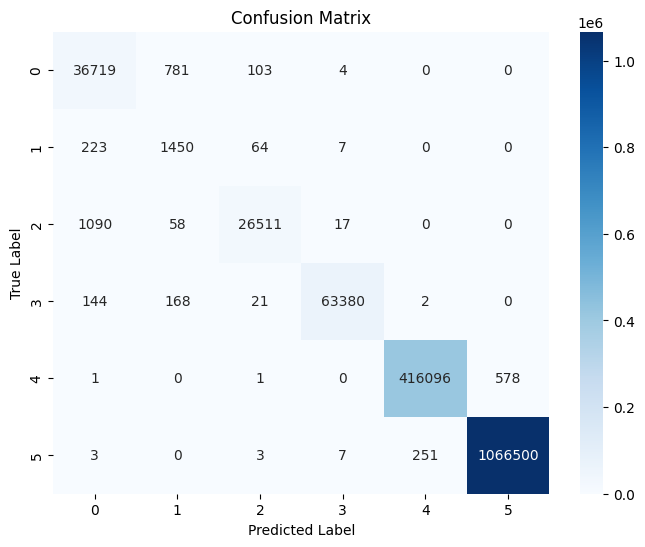

Akurasi: 1.00
Presisi: 0.92
Recall: 0.96
F1 Score: 0.94


In [16]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# Misalkan dtrain dan dtest sudah didefinisikan
# Training model seperti yang sudah Anda lakukan
params = {
    'objective': 'multi:softmax',  # Objective untuk multi-kelas
    'num_class': 6,  # Jumlah kelas
    'max_depth': 6,
    'eta': 0.3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

num_boost_round = 100
bst = xgb.train(params, dtrain, num_boost_round)

# Prediksi pada data test
y_pred = bst.predict(dtest)

# Asumsi dtest label tersedia sebagai y_test
y_test = dtest.get_label()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Menghitung metrik
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

In [17]:

print(f'Akurasi: {accuracy:.3f}')
print(f'Presisi: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')

Akurasi: 0.998
Presisi: 0.924
Recall: 0.960
F1 Score: 0.938


In [19]:
import pickle
# Save model to a .pkl file
with open('xgboost_model.pkl', 'wb') as file:
    pickle.dump(bst, file)

print("Model berhasil disimpan ke 'xgboost_model.pkl'")

Model berhasil disimpan ke 'xgboost_model.pkl'


In [20]:
# Save the scaler
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(X_train_scaled, scaler_file)